# Notebook de documentacion, tratamiento datos y entrenamiento


## Equipo
- Alumno 1 : 
- Alumno 2 :

In [ ]:
## TO-DO utiliza esta notebook para documentar, entrenar y probar el modelo.

In [1]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from facenet_pytorch import MTCNN, InceptionResnetV1
from sklearn.datasets import fetch_lfw_people
from sklearn.metrics import roc_curve, auc
from sklearn.manifold import TSNE
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch: {torch.__version__} | Dispositivo: {device}")

c:\Users\Nicolas\Desktop\tuia-face-recognition-app\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch: 2.2.2+cpu | Dispositivo: cpu


In [4]:
from pathlib import Path

Se tiene un total de 5 imágenes


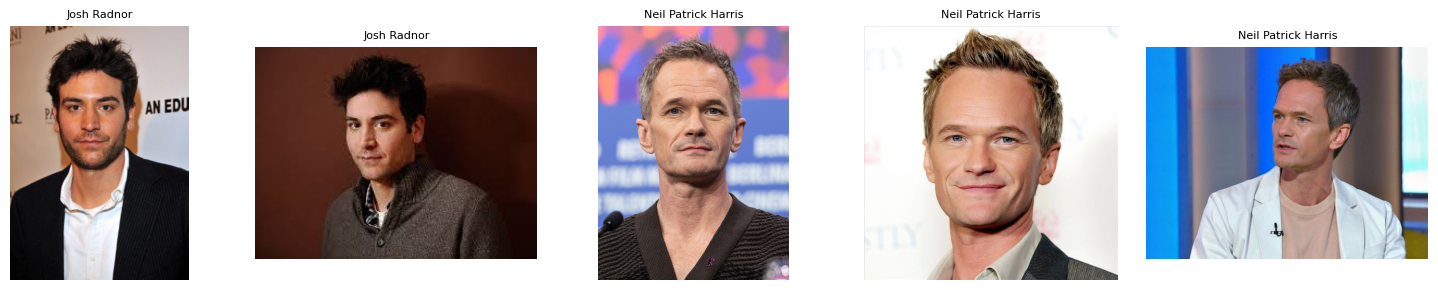

In [6]:
ruta = Path("src\data\Imagenes")

paths = []
labels = []

for person_dir in sorted(ruta.iterdir()):
    for imagen in sorted(person_dir.glob("*.jpg")):
        paths.append(imagen)
        labels.append(person_dir.name)

print(f"Se tiene un total de {len(paths)} imágenes")
fig, axes = plt.subplots(1, len(paths), figsize = (3 * len(paths), 3))
if len(paths) == 1:
    axes = [axes]
for ax, path, label in zip(axes, paths, labels):
    ax.imshow(Image.open(path))
    ax.set_title(label, fontsize = 8)
    ax.axis("off")
plt.tight_layout()
plt.show()

In [9]:
mtcnn = MTCNN(image_size = 160, keep_all = True, device = device, margin = 20)

In [10]:
import matplotlib.patches as patches

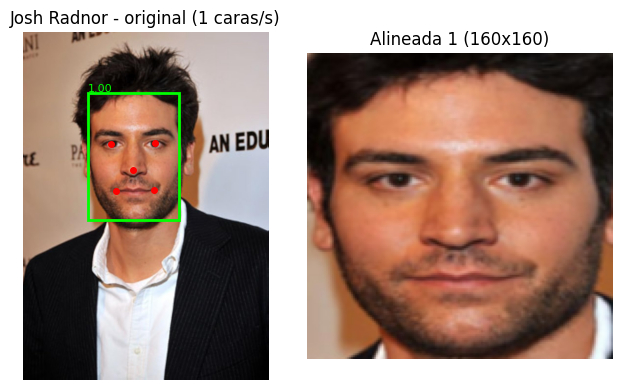

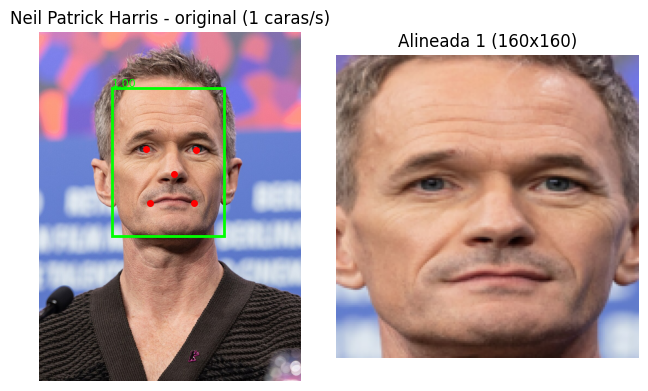

In [14]:
visto = set()
for path, label in zip(paths, labels):
    if label in visto:
        continue
    visto.add(label)

    img = Image.open(path).convert("RGB")
    boxes, probs, landmarks = mtcnn.detect(img, landmarks=True)
    face_tensor = mtcnn(img)

    n = 0 if boxes is None else len(boxes)
    fig, axes = plt.subplots(1, 1 + n, figsize = (4 + 2.5 * n, 4))
    if not isinstance(axes, np.ndarray):
        axes = [axes]

    axes[0].imshow(img)
    axes[0].set_title(f"{label} - original ({n} caras/s)")
    axes[0].axis("off")
    if boxes is not None:
        for box, prob, kps in zip(boxes, probs, landmarks):
            x1, y1, x2, y2 = box.astype(int)
            axes[0].add_patch(patches.Rectangle((x1, y1), x2-x1, y2-y1, linewidth = 2, edgecolor = 'lime', facecolor = "none"))
            axes[0].text(x1, y1 - 5, f"{prob:.2f}", color = "lime", fontsize = 8)
            for kp in kps:
                axes[0].plot(kp[0], kp[1], "r.", markersize = 8)
            
    if face_tensor is not None:
        faces = face_tensor if face_tensor.ndim == 4 else face_tensor.unsqueeze(0)
        for i, t in enumerate(faces):
            face_np = ((t.permute(1, 2, 0).numpy() + 1) * 127.5).clip(0, 255).astype(np.uint8)
            axes[1 + i].imshow(face_np)
            axes[1 + i].set_title(f"Alineada {i+1} (160x160)")
            axes[1 + i].axis("off")
    
    plt.tight_layout()
    plt.show()